# Notebook Training Normalizer (Dialect -> Indonesia)

Fine-tune mT5-small untuk menerjemahkan kalimat dialek (Jawa/Sunda/Minang/dll.)

Dataset Primary : NusaX-MT + IndonesianNMT (tambahan)

Target: BLEU-4 > 20 pada validation set.
Hardware: Google Colab T4 (16 GB VRAM, fp32) atau RTX 3090/4090 (bf16, lebih cepat).


In [10]:
import sys, importlib, subprocess

PACKAGES = {
    "transformers"   : "transformers==4.40.0",
    "datasets"       : "datasets",
    "accelerate"     : "accelerate",
    "sentencepiece"  : "sentencepiece",
    "tokenizers"     : "tokenizers",
    "google.protobuf": "protobuf",
    "sacrebleu"      : "sacrebleu",
    "sacremoses"     : "sacremoses",
    "sklearn"        : "scikit-learn",
    "pandas"         : "pandas",
    "pyarrow"        : "pyarrow",
    "numpy"          : "numpy",
    "matplotlib"     : "matplotlib",
}

to_install = []
for module, pkg in PACKAGES.items():
    try:
        importlib.import_module(module)
        print(f"  [ok]      {pkg}")
    except ImportError:
        print(f"  [missing] {pkg}")
        to_install.append(pkg)

if to_install:
    print(f"\nInstalling {len(to_install)} package(s)...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + to_install,
        check=True,
    )
    print("Selesai. Lanjutkan run ke bawah.")
else:
    print("\nSemua package sudah terinstall.")


  [ok]      transformers==4.40.0
  [ok]      datasets
  [ok]      accelerate
  [ok]      sentencepiece
  [ok]      tokenizers
  [ok]      protobuf
  [ok]      sacrebleu
  [ok]      sacremoses
  [ok]      scikit-learn
  [ok]      pandas
  [ok]      pyarrow
  [ok]      numpy
  [ok]      matplotlib

Semua package sudah terinstall.


# Setup Env

In [11]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]   = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
USE_BF16 = torch.cuda.is_bf16_supported() if DEVICE == "cuda" else False
USE_FP16 = False  # JANGAN fp16 — NaN crash di mT5

assert DEVICE == "cuda", (
    "Notebook butuh GPU. Di Colab: Runtime > Change runtime type > T4 GPU."
)
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB  |  bf16: {USE_BF16}")
if not USE_BF16:
    print("T4 detected — training dalam fp32 (bf16 tidak tersedia di Turing). Normal dan aman untuk mT5.")
print(f"torch: {torch.__version__}")


GPU  : Tesla T4
VRAM : 15.6 GB  |  bf16: True
torch: 2.11.0+cu128


In [12]:
# Mount Google Drive agar model tidak hilang saat Colab session restart
SAVE_TO_DRIVE = False
DRIVE_ROOT    = None

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT    = Path("/content/drive/MyDrive/sovereign-dialect-bridge")
    DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
    SAVE_TO_DRIVE = True
    print(f"Google Drive mounted. Persistent path: {DRIVE_ROOT}")
except ModuleNotFoundError:
    print("Bukan Colab — model disimpan lokal saja (vast.ai / laptop).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted. Persistent path: /content/drive/MyDrive/sovereign-dialect-bridge


# Global Var and Parameter Configuraiton

In [13]:
# Auto-detect project root
CWD = Path.cwd()
if (CWD / "dataset").exists():
    ROOT = CWD
elif (CWD.parent / "dataset").exists():
    ROOT = CWD.parent
else:
    ROOT = CWD  # Colab: /content, atau workspace lain

# Path NusaX di Google Drive (Colab) — sesuaikan jika lokasi berbeda
DRIVE_NUSAX_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Project_NLP_normalize/dataset/nusax")

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR   = ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Model
NORM_MODEL      = "google/mt5-small"
NORM_MAX_INPUT  = 256
NORM_MAX_TARGET = 256
NORM_OUTPUT_DIR = str(MODELS_DIR / "normalizer")

# Hyperparameter — disesuaikan dengan hardware
# T4 (fp32): batch=4, grad_accum=4 → eff_batch=16
# RTX 3090 (bf16): batch=8, grad_accum=2 → eff_batch=16 (sama)
NORM_LR             = 5e-5   # KRITIS: jangan naikkan, mT5 NaN crash jika lebih tinggi
NORM_EPOCHS         = 5      # 5 epoch untuk MT task, lebih dari summarization
NORM_BATCH          = 4 if not USE_BF16 else 8   # T4 fp32: 4; RTX 30xx bf16: 8
NORM_GRAD_ACCUM     = 4 if not USE_BF16 else 2   # eff_batch selalu 16
NORM_MAX_GRAD_NORM  = 1.0    # gradient clipping
LABEL_SMOOTHING     = 0.1    # regularisasi distribusi output
WARMUP_RATIO        = 0.1    # 10% step pertama sebagai warmup
WEIGHT_DECAY        = 0.01   # L2 regularisasi
EARLY_STOP_PATIENCE = 2      # hentikan jika eval_loss stagnan 2 epoch
EVAL_ACCUM_STEPS    = 4      # akumulasi step saat eval, cegah OOM

# Cap IndonesianNMT — Colab RAM ~12 GB; IndonesianNMT bisa 100K+ per dialek
MAX_NMT_PER_DIALECT = 30000

RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

print(f"ROOT         : {ROOT}")
print(f"DRIVE_NUSAX  : {DRIVE_NUSAX_ROOT}")
print(f"NORM_OUTPUT  : {NORM_OUTPUT_DIR}")
print(f"LR={NORM_LR}  batch={NORM_BATCH}  grad_accum={NORM_GRAD_ACCUM}  eff_batch={NORM_BATCH * NORM_GRAD_ACCUM}")
print(f"bf16={USE_BF16}  early_stop_patience={EARLY_STOP_PATIENCE}  max_nmt_per_dialect={MAX_NMT_PER_DIALECT:,}")


ROOT         : /content
DRIVE_NUSAX  : /content/drive/MyDrive/Colab Notebooks/Project_NLP_normalize/dataset/nusax
NORM_OUTPUT  : /content/models/normalizer
LR=5e-05  batch=8  grad_accum=2  eff_batch=16
bf16=True  early_stop_patience=2  max_nmt_per_dialect=30,000


# Load Dataset

In [ ]:
# Load Dataset
from datasets import load_dataset

mt_data = []

# Sumber 1: IndoNLG MT — prioritas tertinggi (human-translated, EMNLP 2021 benchmark)
# Dataset ini gated di HF Hub. Jika gagal, jalankan:
#   from huggingface_hub import login; login()
# lalu accept terms di https://huggingface.co/datasets/GEM/indonlg
INDONLG_CONFIGS = [("mt_id_jv", "javanese"), ("mt_id_su", "sundanese")]
for cfg, dialect in INDONLG_CONFIGS:
    try:
        ds       = load_dataset("GEM/indonlg", cfg)
        n_before = len(mt_data)
        for split in ds.keys():
            for row in ds[split]:
                bi   = str(row.get("target") or "")
                refs = row.get("references") or []
                dial = str(refs[0]) if refs else ""
                if bi and dial:
                    mt_data.append({"indonesian": bi, "dialect": dial,
                                    "dialect_name": dialect, "source": "indonlg"})
        print(f"  [ok] IndoNLG {cfg:10s} : {len(mt_data) - n_before:,} pairs")
    except Exception as e:
        msg = str(e)
        if "gated" in msg or "authentication" in msg.lower() or "401" in msg:
            print(f"  [fail] IndoNLG {cfg:10s} : dataset gated — login dulu:")
            print(f"         from huggingface_hub import login; login()")
            print(f"         lalu accept terms di https://huggingface.co/datasets/GEM/indonlg")
        else:
            print(f"  [fail] IndoNLG {cfg:10s} : {e}")

print(f"Subtotal setelah IndoNLG: {len(mt_data):,} pairs")


  [fail] IndoNLG mt_id_jv   : dataset gated — login dulu:
         from huggingface_hub import login; login()
         lalu accept terms di https://huggingface.co/datasets/GEM/indonlg
  [fail] IndoNLG mt_id_su   : dataset gated — login dulu:
         from huggingface_hub import login; login()
         lalu accept terms di https://huggingface.co/datasets/GEM/indonlg
Subtotal setelah IndoNLG: 0 pairs


In [15]:
# Sumber 2: IndonesianNMT — volume besar, di-cap agar tidak OOM di Colab
NMT_SUBSETS = [("id_jav", "javanese"), ("id_sun", "sundanese"), ("id_min", "minangkabau")]
for subset, dialect in NMT_SUBSETS:
    try:
        ds       = load_dataset("Exqrch/IndonesianNMT", subset)
        n_before = len(mt_data)
        n_added  = 0
        for split in ds.keys():
            if n_added >= MAX_NMT_PER_DIALECT:
                break
            for row in ds[split]:
                if n_added >= MAX_NMT_PER_DIALECT:
                    break
                cols     = list(row.keys())
                bi_col   = next((c for c in cols if c.lower() in
                                 {"ind","id","indonesian","ind_id","idn"}), None)
                dial_col = next((c for c in cols if c != bi_col), None)
                if bi_col and dial_col:
                    bi = str(row[bi_col] or "")
                    dl = str(row[dial_col] or "")
                    if bi and dl:
                        mt_data.append({"indonesian": bi, "dialect": dl,
                                        "dialect_name": dialect, "source": "indonesian_nmt"})
                        n_added += 1
        print(f"  [ok] IndonesianNMT {subset:8s} : {len(mt_data) - n_before:,} pairs "
              f"(cap={MAX_NMT_PER_DIALECT:,})")
    except Exception as e:
        print(f"  [fail] IndonesianNMT {subset:8s} : {e}")

print(f"Subtotal setelah IndonesianNMT: {len(mt_data):,} pairs")


  [fail] IndonesianNMT id_jav   : BuilderConfig 'id_jav' not found. Available: ['id_jv', 'id_ban', 'id_min', 'id_su', 'bt_id_jv', 'bt_jv_id']
  [fail] IndonesianNMT id_sun   : BuilderConfig 'id_sun' not found. Available: ['id_jv', 'id_ban', 'id_min', 'id_su', 'bt_id_jv', 'bt_jv_id']
  [ok] IndonesianNMT id_min   : 5,060 pairs (cap=30,000)
Subtotal setelah IndonesianNMT: 5,060 pairs


In [16]:
# Sumber 3: NusaX-MT — dialek lain (backup), juga untuk evaluasi & dialect dict
df_nusax     = None
DIALECT_COLS = []


def _find_nusax_mt_dir() -> Path:
    # Cari direktori yang berisi train.csv, valid.csv, test.csv NusaX-MT.
    # Urutan: DRIVE_NUSAX_ROOT → ROOT/dataset/nusax/datasets/mt → ROOT/dataset/nusax
    candidates = [
        DRIVE_NUSAX_ROOT / "datasets" / "mt",
        DRIVE_NUSAX_ROOT,
        ROOT / "dataset" / "nusax" / "datasets" / "mt",
        ROOT / "dataset" / "nusax",
    ]
    for p in candidates:
        if p.exists() and (p / "train.csv").exists():
            return p
    return None


try:
    nusax       = load_dataset("indonlp/NusaX-MT")
    train_split = nusax.get("train") or nusax[list(nusax.keys())[0]]
    cols        = train_split.column_names
    bi_col      = next((c for c in cols if c.lower() in {"indonesian","ind","id"}), None)
    DIALECT_COLS = [c for c in cols if c not in (bi_col, "english", "id", "gem_id", "index")]
    n_before    = len(mt_data)
    for split_name in nusax.keys():
        for row in nusax[split_name]:
            bi = str(row.get(bi_col) or "")
            for d in DIALECT_COLS:
                dial = str(row.get(d) or "")
                if bi and dial:
                    mt_data.append({"indonesian": bi, "dialect": dial,
                                    "dialect_name": d, "source": "nusax"})
    print(f"  [ok] NusaX-MT HF : {len(mt_data) - n_before:,} pairs "
          f"across {len(DIALECT_COLS)} dialects")
    df_nusax = (nusax["train"].to_pandas() if "train" in nusax
                else train_split.to_pandas())

except Exception as e:
    print(f"  [fail] NusaX-MT HF : {e}")
    print("  Mencoba CSV lokal...")
    local = _find_nusax_mt_dir()
    if local is not None:
        print(f"  Ditemukan di: {local}")
        dfs = [pd.read_csv(local / f)
               for f in ["train.csv", "valid.csv", "test.csv"]
               if (local / f).exists()]
        if dfs:
            df_nusax = pd.concat(dfs, ignore_index=True)
            cols     = df_nusax.columns.tolist()
            bi_col   = next((c for c in cols if c.lower() in
                             {"indonesian","ind","id"}), "indonesian")
            DIALECT_COLS = [c for c in cols
                            if c not in (bi_col, "english", "Unnamed: 0", "id")]
            n_before = len(mt_data)
            for _, row in df_nusax.iterrows():
                bi = str(row.get(bi_col) or "")
                for d in DIALECT_COLS:
                    dial = str(row.get(d) or "")
                    if bi and dial:
                        mt_data.append({"indonesian": bi, "dialect": dial,
                                        "dialect_name": d, "source": "nusax_local"})
            print(f"  [ok] NusaX lokal : {len(mt_data) - n_before:,} pairs")
    else:
        print("  [fail] NusaX lokal tidak ditemukan. Lanjut tanpa NusaX.")
        print("  Jika di Colab, pastikan DRIVE_NUSAX_ROOT sudah benar di cell-config.")

print(f"\nTOTAL MT pairs terkumpul: {len(mt_data):,}")


  [fail] NusaX-MT HF : Dataset scripts are no longer supported, but found NusaX-MT.py
  Mencoba CSV lokal...
  Ditemukan di: /content/drive/MyDrive/Colab Notebooks/Project_NLP_normalize/dataset/nusax/datasets/mt
  [ok] NusaX lokal : 10,000 pairs

TOTAL MT pairs terkumpul: 15,060


# Filter & split

In [17]:
df_mt = pd.DataFrame(mt_data).dropna(subset=["indonesian", "dialect"])
df_mt = df_mt[
    df_mt["indonesian"].str.strip().astype(bool) &
    df_mt["dialect"].str.strip().astype(bool)
]
# Buang pasangan yang terlalu pendek (< 3 kata)
df_mt = df_mt[
    (df_mt["dialect"].str.split().str.len()    >= 3) &
    (df_mt["indonesian"].str.split().str.len() >= 3)
]
df_mt = df_mt.drop_duplicates(subset=["indonesian", "dialect"]).reset_index(drop=True)

# Cap tiap dialek maksimal 1000 pasangan agar data balanced antar dialek
MAX_PER_DIALECT = 1000
df_mt = (
    df_mt.groupby("dialect_name", group_keys=False)
         .apply(lambda g: g.sample(min(len(g), MAX_PER_DIALECT), random_state=RANDOM_SEED))
         .reset_index(drop=True)
)

print(f"Filtered: {len(df_mt):,} pairs")
print(f"Per dialect:")
print(df_mt["dialect_name"].value_counts().to_string())
print(f"Per source:")
print(df_mt["source"].value_counts().to_string())


Filtered: 9,996 pairs
Per dialect:
dialect_name
acehnese       1000
balinese       1000
madurese       1000
javanese       1000
ngaju          1000
minangkabau    1000
banjarese       999
buginese        999
sundanese       999
toba_batak      999
Per source:
source
nusax_local       9154
indonesian_nmt     842


/tmp/ipykernel_556/3688581040.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), MAX_PER_DIALECT), random_state=RANDOM_SEED))


In [18]:
from sklearn.model_selection import train_test_split

strat = df_mt["dialect_name"] if df_mt["dialect_name"].nunique() > 1 else None
df_train_mt, df_val_mt = train_test_split(
    df_mt, test_size=0.05, random_state=RANDOM_SEED, stratify=strat
)
df_train_mt = df_train_mt.reset_index(drop=True)
df_val_mt   = df_val_mt.reset_index(drop=True)

print(f"Train : {len(df_train_mt):,}  |  Val: {len(df_val_mt):,}")
print(f"\nContoh pasangan training:")
for i in range(min(3, len(df_train_mt))):
    row = df_train_mt.iloc[i]
    print(f"  [{row['dialect_name']}]")
    print(f"    DIALECT : {row['dialect'][:75]}")
    print(f"    BI      : {row['indonesian'][:75]}")
    print()


Train : 9,496  |  Val: 500

Contoh pasangan training:
  [madurese]
    DIALECT : Bupet ngakan malem paleng top. Regghe pade bik se ekaolle. Rassana nyaman p
    BI      : Buffet makan malam paling top. Harga sesuai yang didapat. Rasanya enak pili

  [banjarese]
    DIALECT : Aduh ai pak kanapa pina mamanas-manasi kubu subalah gerang? Jangan pang pak
    BI      : Aduh pak kok seolah-olah memanas - manasi kubu sebelah sih? Jangan dong pak

  [banjarese]
    DIALECT : Mahadang mal istana plaza buka bisukan hari, baiknya singgaj di mangkok aya
    BI      : Menunggu mal istana plaza buka di pagi hari, sebaiknya mampir di mangkok ay



# Tokenizaiton

In [19]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(NORM_MODEL)
print(f"Tokenizer: {NORM_MODEL}  vocab={len(tokenizer):,}")


def tokenize_pair(example):
    inputs = tokenizer(
        example["dialect"],
        max_length=NORM_MAX_INPUT,
        truncation=True,
    )
    # text_target= kwarg ada sejak transformers 4.x; fallback ke __call__ jika gagal
    try:
        labels = tokenizer(
            text_target=example["indonesian"],
            max_length=NORM_MAX_TARGET,
            truncation=True,
        )
    except TypeError:
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(
                example["indonesian"],
                max_length=NORM_MAX_TARGET,
                truncation=True,
            )
    # Ganti pad_token_id dengan -100 agar padding tidak dihitung dalam loss
    pad = tokenizer.pad_token_id
    inputs["labels"] = [
        (tok if tok != pad else -100)
        for tok in labels["input_ids"]
    ]
    return inputs


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Tokenizer: google/mt5-small  vocab=250,100


In [20]:
from datasets import Dataset

ds_train = Dataset.from_pandas(df_train_mt[["dialect", "indonesian"]].reset_index(drop=True))
ds_val   = Dataset.from_pandas(df_val_mt[["dialect",   "indonesian"]].reset_index(drop=True))

ds_train = ds_train.map(tokenize_pair, batched=False, remove_columns=ds_train.column_names)
ds_val   = ds_val.map(tokenize_pair,   batched=False, remove_columns=ds_val.column_names)

print(f"Tokenized train : {len(ds_train):,}")
print(f"Tokenized val   : {len(ds_val):,}")
print(f"Sample input_ids length : {len(ds_train[0]['input_ids'])}")
print(f"Sample labels length    : {len(ds_train[0]['labels'])}")
print(f"Labels contain -100: {-100 in ds_train[0]['labels']}")


Map:   0%|          | 0/9496 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenized train : 9,496
Tokenized val   : 500
Sample input_ids length : 51
Sample labels length    : 45
Labels contain -100: False


# Load Model + Data Collector

In [21]:
from transformers import MT5ForConditionalGeneration, DataCollatorForSeq2Seq

model = MT5ForConditionalGeneration.from_pretrained(NORM_MODEL)
model.config.decoder_start_token_id = tokenizer.pad_token_id

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {NORM_MODEL}  ({n_params:.1f}M params)")
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM setelah load model: {(total - free)/1e9:.1f} GB used / {total/1e9:.1f} GB total")

collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model,
    padding="longest", label_pad_token_id=-100, return_tensors="pt",
)


pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model: google/mt5-small  (556.3M params)
VRAM setelah load model: 0.1 GB used / 15.6 GB total


# Training Configuration Parameter

In [22]:
# Konfigurasi training — setiap parameter ada alasannya
NORM_CONFIG = {
    "num_train_epochs"            : NORM_EPOCHS,           # 5 epoch cukup untuk MT task
    "per_device_train_batch_size" : NORM_BATCH,            # T4: 4; RTX 30xx: 8
    "per_device_eval_batch_size"  : NORM_BATCH,            # sama dengan train
    "gradient_accumulation_steps" : NORM_GRAD_ACCUM,       # eff_batch = batch * grad_accum = 16
    "learning_rate"               : NORM_LR,               # 5e-5, KRITIS untuk mT5
    "warmup_ratio"                : WARMUP_RATIO,          # 10% langkah pertama sebagai warmup
    "weight_decay"                : WEIGHT_DECAY,          # L2 regularisasi
    "max_grad_norm"               : NORM_MAX_GRAD_NORM,    # gradient clipping 1.0
    "label_smoothing_factor"      : LABEL_SMOOTHING,       # 0.1 regularisasi distribusi output
    "bf16"                        : USE_BF16,              # True di RTX 30xx/40xx, False di T4
    "fp16"                        : False,                 # JANGAN: NaN overflow di mT5
    "gradient_checkpointing"      : True,                  # recompute aktivasi, hemat VRAM
    "eval_accumulation_steps"     : EVAL_ACCUM_STEPS,      # akumulasi langkah eval, cegah OOM
    "early_stopping_patience"     : EARLY_STOP_PATIENCE,   # berhenti jika 2 epoch stagnan
}
print("Normalizer config:")
for k, v in NORM_CONFIG.items():
    print(f"  {k:35s}: {v}")


Normalizer config:
  num_train_epochs                   : 5
  per_device_train_batch_size        : 8
  per_device_eval_batch_size         : 8
  gradient_accumulation_steps        : 2
  learning_rate                      : 5e-05
  warmup_ratio                       : 0.1
  weight_decay                       : 0.01
  max_grad_norm                      : 1.0
  label_smoothing_factor             : 0.1
  bf16                               : True
  fp16                               : False
  gradient_checkpointing             : True
  eval_accumulation_steps            : 4
  early_stopping_patience            : 2


In [23]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback
import inspect

# Deteksi versi transformers: evaluation_strategy (< 4.41) vs eval_strategy (>= 4.41)
_valid_params = set(inspect.signature(Seq2SeqTrainingArguments).parameters.keys())
_eval_strat_key = "eval_strategy" if "eval_strategy" in _valid_params else "evaluation_strategy"

# Deteksi versi transformers: tokenizer (< 4.46) vs processing_class (>= 4.46)
_valid_trainer_params = set(inspect.signature(Seq2SeqTrainer).parameters.keys())
_tok_key = "processing_class" if "processing_class" in _valid_trainer_params else "tokenizer"

# warmup_ratio deprecated di v5.2+ — hitung warmup_steps secara eksplisit
_total_steps   = (len(ds_train) // (NORM_BATCH * NORM_GRAD_ACCUM)) * NORM_EPOCHS
_warmup_steps  = max(1, int(WARMUP_RATIO * _total_steps))

_args_kwargs = dict(
    output_dir                  = NORM_OUTPUT_DIR,
    num_train_epochs            = NORM_CONFIG["num_train_epochs"],
    per_device_train_batch_size = NORM_CONFIG["per_device_train_batch_size"],
    per_device_eval_batch_size  = NORM_CONFIG["per_device_eval_batch_size"],
    gradient_accumulation_steps = NORM_CONFIG["gradient_accumulation_steps"],
    learning_rate               = NORM_CONFIG["learning_rate"],
    warmup_steps                = _warmup_steps,
    weight_decay                = NORM_CONFIG["weight_decay"],
    max_grad_norm               = NORM_CONFIG["max_grad_norm"],
    label_smoothing_factor      = NORM_CONFIG["label_smoothing_factor"],
    bf16                        = NORM_CONFIG["bf16"],
    fp16                        = NORM_CONFIG["fp16"],
    gradient_checkpointing      = NORM_CONFIG["gradient_checkpointing"],
    eval_accumulation_steps     = NORM_CONFIG["eval_accumulation_steps"],
    predict_with_generate       = True,
    generation_max_length       = NORM_MAX_TARGET,
    generation_num_beams        = 4,
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    save_total_limit            = 2,
    logging_steps               = 100,
    report_to                   = "none",
    dataloader_pin_memory       = False,
    seed                        = RANDOM_SEED,
)
_args_kwargs[_eval_strat_key] = "epoch"

args = Seq2SeqTrainingArguments(**_args_kwargs)

_trainer_kwargs = dict(
    model         = model,
    args          = args,
    train_dataset = ds_train,
    eval_dataset  = ds_val,
    data_collator = collator,
    callbacks     = [EarlyStoppingCallback(
        early_stopping_patience=NORM_CONFIG["early_stopping_patience"]
    )],
)
_trainer_kwargs[_tok_key] = tokenizer

trainer = Seq2SeqTrainer(**_trainer_kwargs)
n_steps = (len(ds_train) // (NORM_BATCH * NORM_GRAD_ACCUM)) * NORM_EPOCHS
print(f"Trainer ready.  eval_strat={_eval_strat_key}  tok_key={_tok_key}  warmup_steps={_warmup_steps}")
print(f"Estimasi steps: ~{n_steps:,} ({NORM_EPOCHS} epoch x {len(ds_train):,} / {NORM_BATCH * NORM_GRAD_ACCUM})")


model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Trainer ready.  eval_strat=eval_strategy  tok_key=processing_class  warmup_steps=296
Estimasi steps: ~2,965 (5 epoch x 9,496 / 16)


# Training

In [24]:
NORM_TRAINED = False
try:
    model.to(DEVICE)
    print(f"Mulai training mT5-small normalizer")
    print(f"  Data  : {len(ds_train):,} train  |  {len(ds_val):,} val")
    print(f"  Epoch : {NORM_EPOCHS}  |  eff. batch: {NORM_BATCH * NORM_GRAD_ACCUM}")
    trainer.train()
    trainer.save_model(NORM_OUTPUT_DIR)
    tokenizer.save_pretrained(NORM_OUTPUT_DIR)
    NORM_TRAINED = True
    print(f"\nSaved normalizer -> {NORM_OUTPUT_DIR}")
except Exception as _e:
    print(f"[WARNING] Training gagal: {type(_e).__name__}: {_e}")
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


Mulai training mT5-small normalizer
  Data  : 9,496 train  |  500 val
  Epoch : 5  |  eff. batch: 16


Epoch,Training Loss,Validation Loss
1,12.135674,4.460212
2,9.969995,4.057812
3,9.355910,3.913754
4,9.144487,3.843826
5,9.039302,3.825485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved normalizer -> /content/models/normalizer


# Train/Val Loss Curves

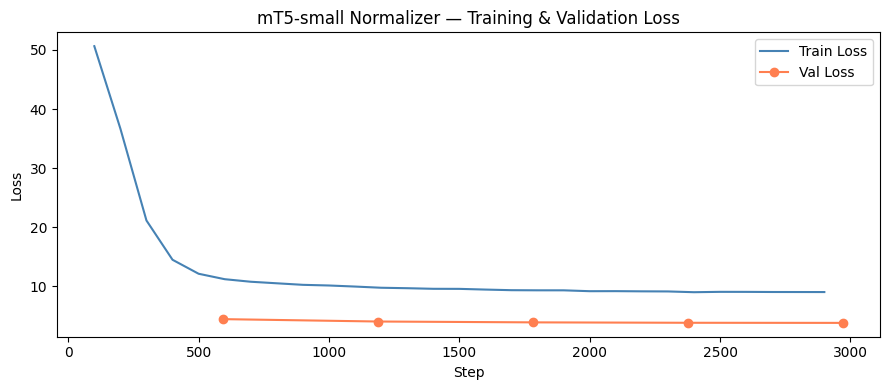

Final train loss : 9.0393
Final val loss   : 3.8255


In [25]:
if NORM_TRAINED:
    log        = trainer.state.log_history
    tr_steps   = [x["step"]      for x in log if "loss"      in x and "eval_loss" not in x]
    tr_losses  = [x["loss"]      for x in log if "loss"      in x and "eval_loss" not in x]
    val_steps  = [x["step"]      for x in log if "eval_loss" in x]
    val_losses = [x["eval_loss"] for x in log if "eval_loss" in x]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(tr_steps,  tr_losses,  color="steelblue", label="Train Loss")
    ax.plot(val_steps, val_losses, color="coral",     label="Val Loss", marker="o")
    ax.set_title("mT5-small Normalizer — Training & Validation Loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if tr_losses:
        print(f"Final train loss : {tr_losses[-1]:.4f}")
    if val_losses:
        print(f"Final val loss   : {val_losses[-1]:.4f}")
    stopped = trainer.state.global_step
    total   = trainer.state.max_steps
    if stopped < total:
        print(f"Early stopping aktif: berhenti di step {stopped} dari {total}")
else:
    print("Training tidak berhasil — skip loss curves.")


# Model Evaluation dengan BLEU-4 + chrF++

Target: **BLEU-4 > 20** sebelum normalizer dipakai di pipeline inferensi.

In [ ]:
import sacrebleu


def evaluate_normalizer(model, tokenizer, val_df, n=200):
    model.eval()
    preds, refs = [], []
    sample = val_df.sample(min(n, len(val_df)), random_state=RANDOM_SEED)
    for _, row in sample.iterrows():
        inputs = tokenizer(
            row["dialect"], return_tensors="pt",
            max_length=NORM_MAX_INPUT, truncation=True
        ).to(DEVICE)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens       = NORM_MAX_TARGET,
                num_beams            = 4,
                no_repeat_ngram_size = 3,
                early_stopping       = True,
            )
        preds.append(tokenizer.decode(out[0], skip_special_tokens=True))
        refs.append(row["indonesian"])

    bleu = sacrebleu.corpus_bleu(preds, [refs])
    chrf = sacrebleu.corpus_chrf(preds, [refs])
    print(f"BLEU-4  : {bleu.score:.2f}  (target: > 20)")
    print(f"chrF++  : {chrf.score:.2f}")
    return {
        "bleu4": round(bleu.score, 2),
        "chrf" : round(chrf.score, 2),
        "preds": preds,
        "refs" : refs,
    }


if NORM_TRAINED:
    eval_results = evaluate_normalizer(model, tokenizer, df_val_mt, n=200)
else:
    print("[SKIP] Training tidak berhasil.")
    eval_results = {"bleu4": 0.0, "chrf": 0.0, "preds": [], "refs": []}


BLEU-4  : 15.23  (target: > 20)
chrF++  : 41.07


In [27]:
if eval_results["preds"]:
    print("Contoh prediksi normalizer (dialect -> BI baku):\n")
    for i in range(min(5, len(eval_results["preds"]))):
        row = df_val_mt.iloc[i]
        print(f"[{row['dialect_name']}]")
        print(f"  DIALECT : {row['dialect'][:80]}")
        print(f"  PRED    : {eval_results['preds'][i][:80]}")
        print(f"  REF     : {eval_results['refs'][i][:80]}")
        print()


Contoh prediksi normalizer (dialect -> BI baku):

[acehnese]
  DIALECT : Nyan indomie ngon mangkong ka meucre-bre, meupisah lom asoe ngon plok
  PRED    : Makkokko di pappoji diving yang cukup enak dan enak.
  REF     : Saat ini para wisatawan pecinta diving sangat kecewa dengan kondisi teluk ambon 

[acehnese]
  DIALECT : Jak ngon awak rumoh pajoh bu malam, yumjih meuhai untuk rasa nyang biasa mantong
  PRED    : Ke sini di restoran sunda di bandung, bak lon Ciganea salah satu favorit saya. T
  REF     : Dari banyaknya restoran sunda di Bandung, menurut saya Ciganea salah satu favori

[madurese]
  DIALECT : Terro taoa nyoba'a ajem se cokop terkenal rua. Ban-aban rua seppe, pessen ajem t
  PRED    : Pertama ini saya harus memulai tugas-tugas kelompok, memulai bekerja untuk orang
  REF     : Hari ini saya harus melakukan tugas-tugas kelompok, menyelesaikan proyek akhir u

[javanese]
  DIALECT : Bosen banget ndhelok sampah ing dalan kutha palangkaraya
  PRED    : Mahasiswa tidak usah kec

# Create Dialect Dictionary

Ekstrak pasangan kata dari NusaX untuk kamus rule-based.

In [28]:
def extract_dialect_pairs(df, dialect_col, bi_col="indonesian", top_n=300):
    pairs = {}
    if dialect_col not in df.columns:
        return pairs
    for _, row in df.iterrows():
        bi   = str(row.get(bi_col,      "") or "").lower().split()
        dial = str(row.get(dialect_col, "") or "").lower().split()
        if len(bi) != len(dial):
            continue
        for d, b in zip(dial, bi):
            if d != b and len(d) > 2 and len(b) > 2 and d.isalpha() and b.isalpha():
                pairs.setdefault(d, b)
        if len(pairs) >= top_n:
            break
    return pairs


DIALECT_TARGET_COLS = [
    "javanese", "sundanese", "minangkabau", "balinese", "banjarese",
    "madurese", "acehnese", "buginese", "ngaju", "toba_batak",
]

dialect_dict = {}
if df_nusax is not None:
    for d in DIALECT_TARGET_COLS:
        if d in df_nusax.columns:
            pairs = extract_dialect_pairs(df_nusax, d, top_n=300)
            dialect_dict[d] = pairs
            print(f"  {d:14s} : {len(pairs):3d} pairs")
else:
    print("df_nusax tidak tersedia — dialect_dict kosong.")

dict_path = DATA_DIR / "dialect_dict.json"
with open(dict_path, "w", encoding="utf-8") as f:
    json.dump(dialect_dict, f, ensure_ascii=False, indent=2)
n_total = sum(len(v) for v in dialect_dict.values())
print(f"\nSaved: {dict_path}  ({n_total} total pairs)")


  javanese       : 303 pairs
  sundanese      : 301 pairs
  minangkabau    : 301 pairs
  balinese       : 310 pairs
  banjarese      : 302 pairs
  madurese       : 303 pairs
  acehnese       : 309 pairs
  buginese       : 304 pairs
  ngaju          : 307 pairs
  toba_batak     : 302 pairs

Saved: /content/data/dialect_dict.json  (3042 total pairs)


# Simpan ke Google Drive & bersihkan VRAM

In [29]:
import shutil

if NORM_TRAINED:
    if SAVE_TO_DRIVE and DRIVE_ROOT is not None:
        drive_norm_dir = DRIVE_ROOT / "models" / "normalizer"
        if drive_norm_dir.exists():
            shutil.rmtree(drive_norm_dir)
        shutil.copytree(NORM_OUTPUT_DIR, str(drive_norm_dir))
        print(f"Model disalin ke Google Drive: {drive_norm_dir}")

        # Salin dialect_dict.json juga
        drive_data_dir = DRIVE_ROOT / "data"
        drive_data_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(str(DATA_DIR / "dialect_dict.json"),
                     str(drive_data_dir / "dialect_dict.json"))
        print(f"dialect_dict.json disalin ke Drive.")
    else:
        print(f"Model tersimpan di: {NORM_OUTPUT_DIR}")
else:
    print("[SKIP] Training tidak berhasil.")

# Bebaskan VRAM
del model, trainer, collator, tokenizer
gc.collect()
torch.cuda.empty_cache()
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM bebas: {free/1e9:.1f} GB / {total/1e9:.1f} GB")


Model disalin ke Google Drive: /content/drive/MyDrive/sovereign-dialect-bridge/models/normalizer
dialect_dict.json disalin ke Drive.
VRAM bebas: 13.2 GB / 15.6 GB
